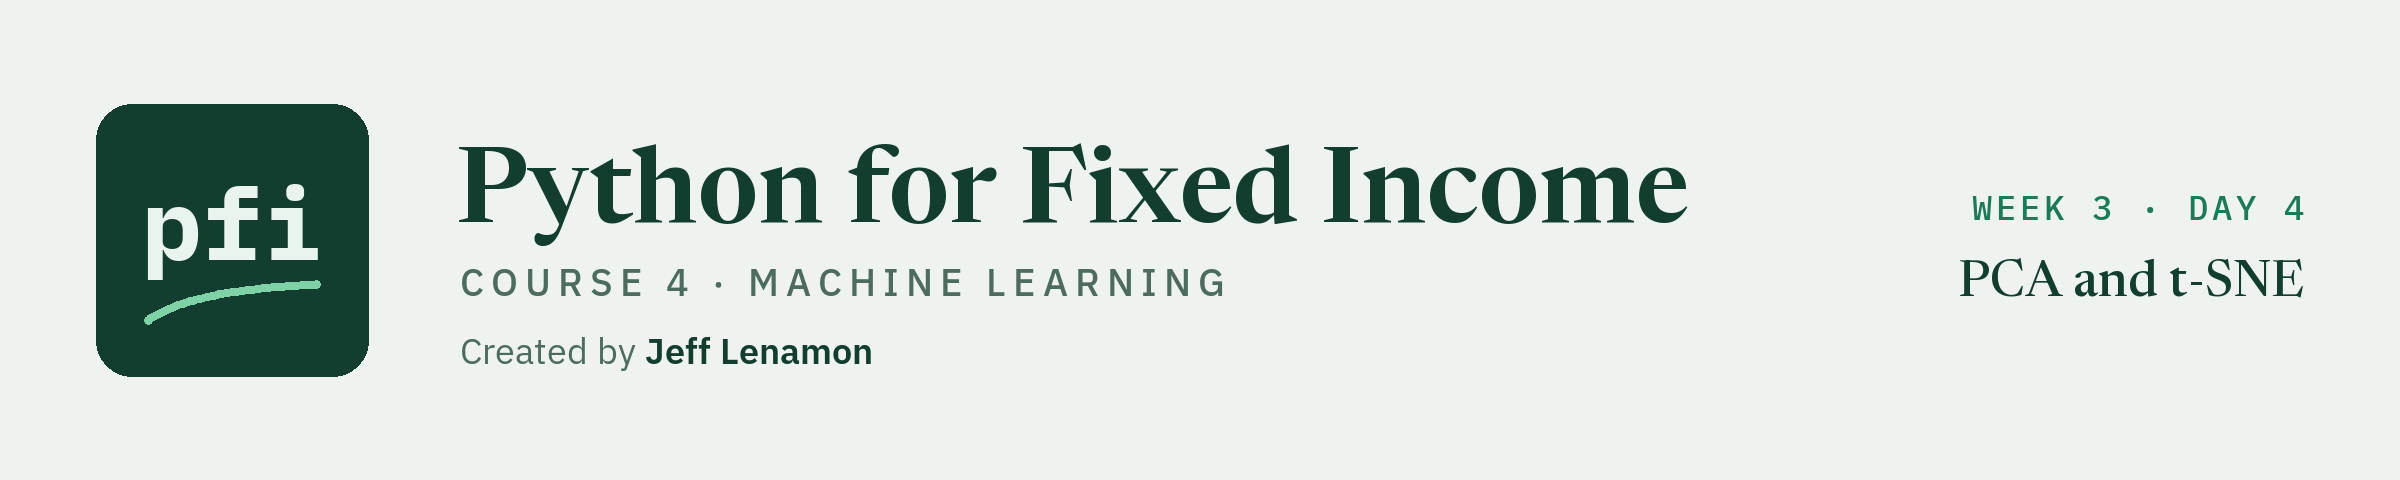

# PCA and t-SNE

Week 3, Day 4. Eleven yields that move together can be summarised by three numbers a day. Today: PCA on the Treasury curve, its loadings and their shapes, explained variance, scores over the file's own history, the sign rule, PCA inside a pipeline, scaling before PCA, and t-SNE as a picture of high-dimensional data.

**Data:** `treasury_par_yields.csv`, daily par yields 2015-01-02 to 2026-10-02: **real**, U.S. Treasury, public domain.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week3/day4/14_pca_and_t_sne.ipynb)

In Course 3, notebook 9, you described the curve's shape with numbers you chose: `2s10s`, `5s30s`, `2s5s10s`. On day 11 you met the problem those choices hide: the tenors move so closely together that a regression on all of them could hardly tell them apart (the 20 Yr and 10 Yr daily changes had a correlation near 0.95).

Today the data choose the numbers. **Principal component analysis (PCA)** finds a few weighted sums of the tenors that carry most of how the curve moved, with no target and nothing to fit to. Yesterday's clustering grouped rows; PCA summarises columns.

**What PCA is called in this course.** The Treasury file is real, and every number from it describes the curve's history from 2015-01-02 to 2026-10-02, inside the file. A component is a shape of movement in that history; a score is how much of that shape a past date had. Level, slope, and curvature are names for the shapes of the loadings. No component says what rates will do, what policy or the economy is doing, or what anyone should do, and nothing is computed for any date after 2026-10-02.

The second half of the day moves to the 821 synthetic benchmark bonds of days 12 and 13, for two lessons PCA and t-SNE share with clustering: units decide distance, so scale first; and a picture of many columns is a picture, not a measurement.

Today you will:

1. See how closely the tenors move together.
2. Run PCA on the levels of the 11 full tenors, and read the loadings as shapes with `pca_loadings` and the variance with `explained_table`.
3. Run PCA on daily changes in bp and tie its components to Course 3's slope and fly.
4. Chart the scores over the file's span, as history.
5. Use PCA as a feature step inside a pipeline only, and prove a fitted PCA uses no later rows.
6. Scale before PCA when the columns have different units.
7. Draw the bonds with t-SNE at three perplexities, and say what the picture can and cannot be trusted for.

Q. Set up today's work folder: the thread settings, the seed, and the course data.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_14_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv", "treasury_par_yields.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_14_vuzyhn5p, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv, treasury_par_yields.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name


from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


def pay0_flags(threshold: float = 0.5) -> tuple[pd.Series, np.ndarray]:
    """Actual defaults and flags of the logistic model on PAY_0, at Excel Solver's coefficients."""
    card = read_card()
    model = "d06_logit_default_on_pay0"
    z = excel(f"{model}:coef_const") + excel(f"{model}:coef_PAY_0") * card["PAY_0"]
    return card[CARD_TARGET], (mlkit.logistic_probability(z) >= threshold).astype(int)


def test_confusion_counts_hand():
    counts = mlkit.confusion_counts([0, 0, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0])
    assert counts == {"tn": 2, "fp": 1, "fn": 1, "tp": 2}


def test_confusion_counts_match_sklearn():
    y, flags = pay0_flags()
    counts = mlkit.confusion_counts(y, flags)
    tn, fp, fn, tp = confusion_matrix(y, flags).ravel()
    assert counts == {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    # Excel: =COUNTIFS(actual, 1, probability, ">=0.5") and the other three
    for name, value in counts.items():
        assert value == excel(f"d07_confusion_pay0_at_0.5:{name}")


def test_metrics_match_sklearn():
    y, flags = pay0_flags()
    metrics = mlkit.classification_metrics(y, flags)
    assert metrics["accuracy"] == pytest.approx(accuracy_score(y, flags), abs=1e-12)
    assert metrics["precision"] == pytest.approx(precision_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["recall"] == pytest.approx(recall_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["f1"] == pytest.approx(f1_score(y, flags, zero_division=0), abs=1e-12)
    for name in ("accuracy", "precision", "recall", "f1"):
        assert metrics[name] == pytest.approx(excel(f"d07_confusion_pay0_at_0.5:{name}"), abs=1e-12)


def test_metrics_zero_division():
    # a model that flags nothing: precision, recall, and F1 are 0 by convention, not an error
    metrics = mlkit.classification_metrics([0, 1, 1, 0], [0, 0, 0, 0])
    assert metrics == {"accuracy": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}


def test_rejects_labels_other_than_0_1():
    with pytest.raises(ValueError, match="other than 0 and 1"):
        mlkit.confusion_counts([0, 1, 2], [0, 1, 1])
    with pytest.raises(ValueError):
        mlkit.classification_metrics([0, 1], [True, 0.5])


from sklearn.metrics import roc_curve


def card_split() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """The card file's 60/20/20 split, stratified, seed 42: 18,000 training, 6,000 validation, 6,000 test rows.
    The four person columns (SEX, EDUCATION, MARRIAGE, AGE) and ID are never features."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
        [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X, y = card[features], card[CARD_TARGET]
    X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=SEED)
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def validation_proba() -> tuple[pd.Series, np.ndarray]:
    """Validation outcomes and probabilities of a scaled logistic regression fitted on the training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    return y_valid, model.predict_proba(X_valid)[:, 1]


def test_threshold_for_recall_hand():
    y = [1, 0, 1, 0, 1, 0]
    proba = [0.9, 0.8, 0.7, 0.4, 0.3, 0.1]
    # at 0.7 two of three defaults are caught (recall 2/3); at 0.3 all three
    assert mlkit.threshold_for_recall(y, proba, 0.6) == 0.7
    assert mlkit.threshold_for_recall(y, proba, 0.7) == 0.3
    assert mlkit.threshold_for_recall(y, proba, 1.0) == 0.3
    # tied probabilities are flagged together
    assert mlkit.threshold_for_recall([1, 1, 0, 1], [0.6, 0.5, 0.5, 0.2], 0.5) == 0.5


def test_threshold_meets_target():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    recall = mlkit.classification_metrics(y_valid, (proba >= threshold).astype(int))["recall"]
    assert recall >= 0.70
    # roc_curve flags rows with score >= threshold too: the true positive rate there is the same recall
    # (drop_intermediate=False keeps every distinct probability as a threshold)
    fpr, tpr, thresholds = roc_curve(y_valid, proba, drop_intermediate=False)
    assert tpr[thresholds == threshold][0] == pytest.approx(recall, abs=1e-12)


def test_threshold_is_highest():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    higher = np.unique(proba[proba > threshold])
    # the next distinct probability above the threshold misses the target
    next_up = higher.min()
    assert mlkit.classification_metrics(y_valid, (proba >= next_up).astype(int))["recall"] < 0.70


def test_threshold_rejects_bad_target():
    for target in (0.0, -0.1, 1.2):
        with pytest.raises(ValueError):
            mlkit.threshold_for_recall([0, 1], [0.2, 0.8], target)
    with pytest.raises(ValueError, match="no row of class 1"):
        mlkit.threshold_for_recall([0, 0], [0.2, 0.8], 0.5)


from sklearn.model_selection import KFold, StratifiedKFold


def test_cv_folds_classification_is_stratified():
    folds = mlkit.cv_folds()
    assert isinstance(folds, StratifiedKFold)
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)
    X_train, _, _, y_train, _, _ = card_split()
    overall = y_train.mean()
    for train_positions, test_positions in folds.split(X_train, y_train):
        mlkit.assert_disjoint(train_positions, test_positions)
        # each fold keeps the training rows' default rate to within one account
        assert abs(y_train.iloc[test_positions].mean() - overall) < 1 / len(test_positions) + 1e-12


def test_cv_folds_regression():
    folds = mlkit.cv_folds("regression")
    assert type(folds) is KFold
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)


def test_cv_folds_rejects_unknown():
    with pytest.raises(ValueError, match="time"):
        mlkit.cv_folds("time")


from sklearn.exceptions import NotFittedError
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier


def fitted_models() -> tuple[dict, pd.DataFrame, pd.Series]:
    """A scaled logistic regression and a depth-3 balanced tree fitted on the card training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    models = {
        "logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
        "tree": DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=SEED),
    }
    for model in models.values():
        model.fit(X_train, y_train)
    return models, X_valid, y_valid


def test_compare_models_columns():
    models, X_valid, y_valid = fitted_models()
    table = mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    assert list(table.index) == ["logistic", "tree"]
    assert list(table.columns) == ["roc_auc", "average_precision", "threshold", "accuracy", "precision", "recall",
                                   "f1"]
    proba = models["logistic"].predict_proba(X_valid)[:, 1]
    assert table.loc["logistic", "roc_auc"] == pytest.approx(roc_auc_score(y_valid, proba), abs=1e-12)
    assert table.loc["logistic", "average_precision"] == pytest.approx(average_precision_score(y_valid, proba),
                                                                         abs=1e-12)
    flags = (proba >= 0.2).astype(int)
    assert table.loc["logistic", "recall"] == pytest.approx(recall_score(y_valid, flags), abs=1e-12)
    with pytest.raises(ValueError, match="tree"):
        mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2})


def test_compare_models_does_not_refit():
    models, X_valid, y_valid = fitted_models()
    before = models["logistic"]["model"].coef_.copy()
    mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    # the coefficients learned on the training rows are untouched
    assert np.array_equal(models["logistic"]["model"].coef_, before)
    # and a model nobody fitted is refused, not fitted on the rows given
    with pytest.raises(NotFittedError):
        mlkit.compare_models({"new": LogisticRegression()}, X_valid, y_valid, {"new": 0.5})


def test_assert_descriptive_passes_plain_text():
    mlkit.assert_descriptive("In this file the model ranked 72 percent of default and non-default pairs correctly. "
                             "A willing reader can check every number.")


def test_assert_descriptive_names_the_word():
    with pytest.raises(ValueError, match=r"\['will', 'cheap'\]"):
        mlkit.assert_descriptive("These bonds look Cheap and spreads WILL tighten.")


from sklearn.model_selection import TimeSeriesSplit


def treasury_dates() -> pd.DatetimeIndex:
    """The 2,940 dates of the Treasury par yield file, 2015-01-02 to 2026-10-02."""
    return pd.DatetimeIndex(pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"])["date"])


def test_walk_forward_hand_index():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2)
    expected = [([0, 1, 2, 3], [4, 5]), ([0, 1, 2, 3, 4, 5], [6, 7]), ([0, 1, 2, 3, 4, 5, 6, 7], [8, 9])]
    assert [(train.tolist(), test.tolist()) for train, test in splits] == expected
    # a last window of one row is dropped
    assert len(mlkit.walk_forward_splits(dates[:9], min_train=4, test_size=2)) == 2


def test_walk_forward_gap():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2, gap=1)
    assert [(train.tolist(), test.tolist()) for train, test in splits] == [
        ([0, 1, 2, 3], [5, 6]), ([0, 1, 2, 3, 4, 5], [7, 8])]
    for train, test in splits:
        mlkit.assert_past_only(dates[train], dates[test], gap=1, calendar=dates)
    # scikit-learn's TimeSeriesSplit with the same test size and gap gives the same positions
    ours = mlkit.walk_forward_splits(dates, min_train=5, test_size=2, gap=1)
    library = TimeSeriesSplit(n_splits=2, test_size=2, gap=1).split(np.zeros(len(dates)))
    assert [(a.tolist(), b.tolist()) for a, b in ours] == [(a.tolist(), b.tolist()) for a, b in library]


def test_walk_forward_past_only():
    dates = treasury_dates()
    # about two years to start, about six months per test window
    splits = mlkit.walk_forward_splits(dates, min_train=504, test_size=126)
    assert len(splits) == (len(dates) - 504) // 126
    for train, test in splits:
        mlkit.assert_disjoint(train, test)
        mlkit.assert_past_only(dates[train], dates[test])
        assert len(test) == 126


def test_walk_forward_rejects_unsorted():
    dates = pd.DatetimeIndex(["2026-01-06", "2026-01-05", "2026-01-07", "2026-01-08"])
    with pytest.raises(ValueError, match="ascending"):
        mlkit.walk_forward_splits(dates, min_train=2, test_size=1)
    with pytest.raises(ValueError, match="unique"):
        mlkit.walk_forward_splits(pd.DatetimeIndex(["2026-01-05"] * 4), min_train=2, test_size=1)


def test_assert_past_only_raises():
    dates = treasury_dates()
    # a shuffled split puts later dates in training: it is refused
    shuffled = KFold(5, shuffle=True, random_state=SEED)
    train, test = next(shuffled.split(np.zeros(len(dates))))
    with pytest.raises(AssertionError, match="not before"):
        mlkit.assert_past_only(dates[train], dates[test])
    # a gap of 5 rows asked for, 0 given
    with pytest.raises(AssertionError, match="gap of 5"):
        mlkit.assert_past_only(dates[:100], dates[100:110], gap=5, calendar=dates)
    with pytest.raises(ValueError, match="calendar"):
        mlkit.assert_past_only(dates[:100], dates[105:110], gap=5)


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def scaled_bonds() -> np.ndarray:
    """log_oas, duration, coupon, and rating score of the 821 bonds, each scaled to mean 0 and standard deviation 1
    (StandardScaler, fitted on every bond: nothing is tested on held-out rows when clustering)."""
    bench = read_bench()
    return StandardScaler().fit_transform(bench[["log_oas", "duration", "coupon", "score"]])


def test_elbow_table_columns_and_ks():
    table = mlkit.elbow_table(scaled_bonds(), range(2, 9))
    assert list(table.index) == list(range(2, 9))
    assert table.index.name == "k"
    assert list(table.columns) == ["inertia", "silhouette"]
    assert table["silhouette"].between(-1, 1).all()
    with pytest.raises(ValueError):
        mlkit.elbow_table(scaled_bonds(), [1, 3])


def test_elbow_inertia_decreases():
    table = mlkit.elbow_table(scaled_bonds(), range(2, 9))
    assert table["inertia"].is_monotonic_decreasing


def test_elbow_matches_kmeans():
    X = scaled_bonds()
    table = mlkit.elbow_table(X, [4])
    model = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X)
    assert table.loc[4, "inertia"] == pytest.approx(model.inertia_, abs=1e-9)
    assert table.loc[4, "silhouette"] == pytest.approx(silhouette_score(X, model.labels_), abs=1e-12)


def test_cluster_profile_counts():
    frame = pd.DataFrame({"oas": [100.0, 120.0, 400.0, 500.0, 600.0]})
    profile = mlkit.cluster_profile(frame, [0, 0, 1, 1, 1], ["oas"])
    assert profile.index.name == "cluster"
    assert profile["count"].tolist() == [2, 3]
    assert profile["oas"].tolist() == [110.0, 500.0]


def test_cluster_profile_original_units():
    bench = read_bench()
    labels = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(scaled_bonds()).labels_
    profile = mlkit.cluster_profile(bench, labels, ["oas", "duration"])
    assert profile["count"].sum() == len(bench)
    for k in profile.index:
        # medians in bp and years, from the unscaled rows
        assert profile.loc[k, "oas"] == bench.loc[labels == k, "oas"].median()
        assert profile.loc[k, "duration"] == bench.loc[labels == k, "duration"].median()
    # in bp, not in scaled units: every median spread is a positive number of bp
    assert (profile["oas"] > 10).all()


def test_cluster_profile_length_mismatch_raises():
    frame = pd.DataFrame({"oas": [100.0, 120.0, 400.0]})
    with pytest.raises(ValueError, match="labels has 2 values"):
        mlkit.cluster_profile(frame, [0, 1], ["oas"])
    with pytest.raises(ValueError, match="duration"):
        mlkit.cluster_profile(frame, [0, 1, 1], ["duration"])

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability', 'confusion_counts', 'classification_metrics', 'threshold_for_recall', 'cv_folds', 'compare_models', 'assert_descriptive', 'walk_forward_splits', 'assert_past_only', 'elbow_table', 'cluster_profile']


* `mlkit.py` arrives with the 19 functions of days 1 to 13. Today adds two: `pca_loadings` and `explained_table`.
* PCA has no randomness here, so `SEED` is used only by t-SNE in section 14.7.

> **STORY: the title says what the method does.** In November 1901 Karl Pearson published a paper titled "On lines and planes of closest fit to systems of points in space" in *The London, Edinburgh, and Dublin Philosophical Magazine and Journal of Science* (volume 2, issue 11, pages 559 to 572). The method this notebook runs is usually traced to it. The title is a fair one-line description of PCA: find the line through a cloud of points that the points sit closest to, then the plane, and so on. Here the points are 2,940 market dates, each a point in eleven dimensions, one per tenor.
>
> Source (read 2026-10-04): the Crossref record of the paper, https://api.crossref.org/works/10.1080/14786440109462720, DOI https://doi.org/10.1080/14786440109462720. Only the title, author, journal, volume, issue, pages, and date are taken from it; the paper itself was not read for this course.

## 14.1 Many Columns That Move Together

Q. Load the Treasury file and keep the tenors that have a value on every date.

Source: U.S. Department of the Treasury, Daily Treasury Par Yield Curve Rates (home.treasury.gov, Interest Rate Statistics), public domain. Yields in percent, as published. The file is real, and everything below describes its history.

In [5]:
# one row per market date, one column per tenor, yields in percent
curve = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
# three tenors start partway through the file; keep the ones with a value on every date
full_tenors = [column for column in curve.columns if curve[column].notna().all()]
levels = curve[full_tenors]
print(f"{len(levels):,} market dates, {levels.index[0].date()} to {levels.index[-1].date()}")
print(f"{len(full_tenors)} full tenors: {full_tenors}")

2,940 market dates, 2015-01-02 to 2026-10-02
11 full tenors: ['1 Mo', '3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', '30 Yr']


Q. Draw the eleven yields over the file's span.

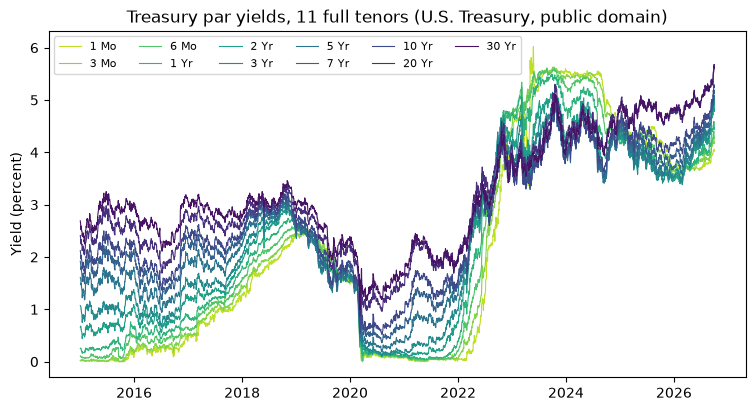

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
# one line per tenor, coloured from short (light) to long (dark)
colours = plt.cm.viridis_r(np.linspace(0.1, 0.95, len(full_tenors)))
for tenor, colour in zip(full_tenors, colours):
    ax.plot(levels.index, levels[tenor], color=colour, linewidth=0.8, label=tenor)
ax.set_title("Treasury par yields, 11 full tenors (U.S. Treasury, public domain)")
ax.set_ylabel("Yield (percent)")
ax.legend(ncol=6, fontsize=8, loc="upper left")
plt.show()

* Eleven lines, and for most of the span they rise and fall together. Where they part, it is mostly the short tenors that sit apart from the long ones. That is the whole idea of today: eleven columns, but far fewer independent ways of moving.

Q. How closely do the daily changes of the 1 Yr to 30 Yr move together?

In [7]:
# the eight tenors from 1 Yr to 30 Yr, as daily changes in bp: today's change less yesterday's level, x 100
tenors = ["1 Yr", "2 Yr", "3 Yr", "5 Yr", "7 Yr", "10 Yr", "20 Yr", "30 Yr"]
changes = (curve[tenors].diff() * 100).dropna()
print(f"{len(changes):,} daily changes in bp, {changes.index[0].date()} to {changes.index[-1].date()}")
changes.corr().round(2)

2,939 daily changes in bp, 2015-01-05 to 2026-10-02


,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
1 Yr,1.00,0.84,0.79,0.72,0.66,0.59,0.47,0.43
2 Yr,0.84,1.00,0.95,0.90,0.83,0.76,0.63,0.57
3 Yr,0.79,0.95,1.00,0.96,0.91,0.85,0.72,0.67
5 Yr,0.72,0.90,0.96,1.00,0.97,0.93,0.83,0.78
7 Yr,0.66,0.83,0.91,0.97,1.00,0.98,0.90,0.86
10 Yr,0.59,0.76,0.85,0.93,0.98,1.00,0.95,0.93
20 Yr,0.47,0.63,0.72,0.83,0.90,0.95,1.00,0.98
30 Yr,0.43,0.57,0.67,0.78,0.86,0.93,0.98,1.00


* Neighbours move almost as one: 20 Yr and 30 Yr at 0.98. Even the furthest pair, 1 Yr and 30 Yr, is at 0.43. Eight columns that correlated carry much less than eight columns' worth of information, which is why day 11's regression on them had trouble telling one tenor from the next.

## 14.2 PCA on Curve Levels: Loadings and Their Shapes

PCA finds a first direction through the data, a set of weights on the tenors, along which the dates spread out the most; then a second, at right angles to the first, which spreads them out the most of what is left; and so on. Each direction is a **component**. Its weights are its **loadings**, and a date's position along it (the date's yields less their averages, times the loadings, summed) is its **score**.

The eleven tenors are all yields in percent, the same unit, so they are used as they are. Scaling is for columns in different units (section 14.6).

Q. Fit a PCA to the 2,940 dates of levels and look at the first three components as scikit-learn returns them.

In [8]:
from sklearn.decomposition import PCA

# every component: as many as there are tenors
pca_levels = PCA().fit(levels)

# components_ holds one row per component and one column per tenor
raw = pd.DataFrame(pca_levels.components_[:3].T, index=full_tenors, columns=["PC1", "PC2", "PC3"])
print(f"components_: {pca_levels.components_.shape[0]} components by {pca_levels.components_.shape[1]} tenors")
print(f"sum of each component's weights: {raw.sum().round(3).to_dict()}")
raw.round(3)

components_: 11 components by 11 tenors
sum of each component's weights: {'PC1': 3.23, 'PC2': 0.744, 'PC3': 0.101}


,PC1,PC2,PC3
1 Mo,0.383,-0.371,0.475
3 Mo,0.384,-0.345,0.213
6 Mo,0.374,-0.281,-0.062
1 Yr,0.352,-0.168,-0.297
2 Yr,0.316,0.029,-0.408
3 Yr,0.290,0.143,-0.386
5 Yr,0.257,0.268,-0.211
7 Yr,0.238,0.323,-0.055
10 Yr,0.225,0.361,0.123
20 Yr,0.219,0.383,0.293


* Each component is a column of eleven weights, one per tenor; each has length 1 (the squares of its weights add to 1).
* **The sign of a component is arbitrary.** A component and the same component times -1 describe the same line through the data: the scores flip sign, and nothing else changes. Which of the two a library returns depends on details of its arithmetic, and can differ between libraries, versions, or a slightly different set of rows. Here all three happen to sum to positive numbers; on another set of rows they may not.

So the course fixes the sign with one rule: **each component is turned so that its loadings sum to a positive number.** That rule lives in `mlkit.pca_loadings`, so a rerun, or a check in another tool, draws the same picture.

Q. Add `pca_loadings` to `mlkit.py`. Read the docstring before you run the cell.

In [9]:
%%writefile -a mlkit.py


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs

Appending to mlkit.py


* `np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)` makes one sign per component; multiplying the table by it flips only the columns that need it.
* The docstring says how scores that match these loadings are computed: `(X - pca.mean_) @ loadings`, the centred data times the loadings. Excel side by side comes back to that.

Q. Add `explained_table`: the share of the variance each component carries, in percent.

In [10]:
%%writefile -a mlkit.py


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Appending to mlkit.py


Q. Reload the module, then read the sign-fixed loadings and the explained variance.

In [11]:
# the file changed, so reload before using the new functions
importlib.reload(mlkit)

loadings_levels = mlkit.pca_loadings(pca_levels, full_tenors)
loadings_levels[["PC1", "PC2", "PC3"]].round(3)

,PC1,PC2,PC3
1 Mo,0.383,-0.371,0.475
3 Mo,0.384,-0.345,0.213
6 Mo,0.374,-0.281,-0.062
1 Yr,0.352,-0.168,-0.297
2 Yr,0.316,0.029,-0.408
3 Yr,0.290,0.143,-0.386
5 Yr,0.257,0.268,-0.211
7 Yr,0.238,0.323,-0.055
10 Yr,0.225,0.361,0.123
20 Yr,0.219,0.383,0.293


* Three shapes, read straight from the weights. **PC1** is positive at every tenor, from 0.193 to 0.384: all yields up together, or all down. That shape is called **level**. **PC2** is negative from 1 Mo to 1 Yr and positive from 2 Yr to 30 Yr: the short end one way, the long end the other. That shape is called **slope**. **PC3** is positive at both ends and negative from 6 Mo to 7 Yr: the ends against the middle. That shape is called **curvature**.
* These are the names of shapes of weights, found in this file's history. They are not statements about what moves rates.

In [12]:
explained_levels = mlkit.explained_table(pca_levels)
explained_levels.head(4).round(2)

,explained_pct,cumulative_pct
PC1,95.62,95.62
PC2,3.38,99.00
PC3,0.86,99.86
PC4,0.08,99.94


* PC1 carries 95.62 percent of the variance of the eleven yields over the span, PC2 3.38, PC3 0.86: together 99.86 percent. Three numbers a date describe almost all of how eleven yields spread out across these 2,940 dates.
* Variance here is spread around each tenor's own average over the file. Levels drift for years at a time, so the level shape takes nearly everything; section 14.3 looks at daily moves instead.

Q. Draw the three shapes.

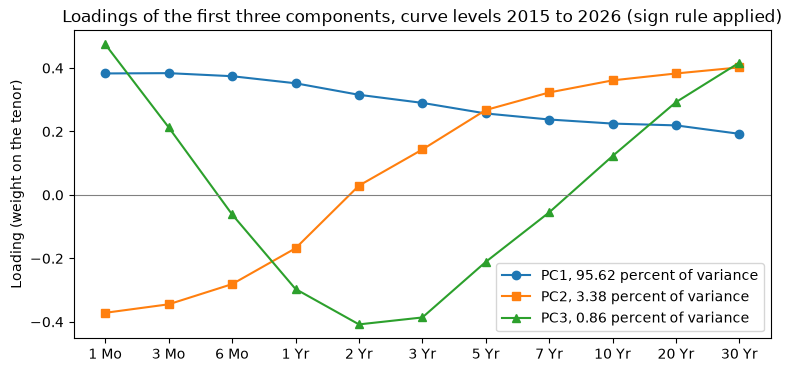

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
positions = range(len(full_tenors))
for name, style in [("PC1", "-o"), ("PC2", "-s"), ("PC3", "-^")]:
    share = explained_levels.loc[name, "explained_pct"]
    ax.plot(positions, loadings_levels[name], style, label=f"{name}, {share:.2f} percent of variance")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(list(positions), full_tenors)
ax.set_title("Loadings of the first three components, curve levels 2015 to 2026 (sign rule applied)")
ax.set_ylabel("Loading (weight on the tenor)")
ax.legend()
plt.show()

* Level, slope, curvature, as shapes across the tenors. The tenors are spaced evenly here, not by maturity, so the short end gets as much room as the long end.

Q. Add the first two tests: the sign rule, and an explained table that adds up to 100 percent.

In [14]:
%%writefile -a test_mlkit.py


from sklearn.decomposition import PCA

TENORS = ["1 Yr", "2 Yr", "3 Yr", "5 Yr", "7 Yr", "10 Yr", "20 Yr", "30 Yr"]


def curve_changes() -> pd.DataFrame:
    """Daily changes in bp of the 1 Yr to 30 Yr Treasury par yields, indexed by date."""
    curve = pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"], index_col="date")
    return (curve[TENORS].diff() * 100).dropna()


def window_scores(changes: pd.DataFrame) -> pd.DataFrame:
    """Fit a 3-component PCA on the rows given and return their scores with the sign-fixed loadings."""
    pca = PCA(n_components=3).fit(changes)
    loadings = mlkit.pca_loadings(pca, list(changes.columns))
    return (changes - pca.mean_) @ loadings


def test_pca_loadings_sign_rule():
    changes = curve_changes()
    pca = PCA(n_components=3).fit(changes)
    loadings = mlkit.pca_loadings(pca, TENORS)
    assert list(loadings.columns) == ["PC1", "PC2", "PC3"]
    assert (loadings.sum(axis=0) > 0).all()
    # flipping a component's sign by hand gives the same loadings back
    pca.components_[1] *= -1
    pd.testing.assert_frame_equal(mlkit.pca_loadings(pca, TENORS), loadings)
    with pytest.raises(ValueError):
        mlkit.pca_loadings(pca, TENORS[:3])


def test_explained_table_sums():
    changes = curve_changes()
    table = mlkit.explained_table(PCA().fit(changes))
    assert table["cumulative_pct"].iloc[-1] == pytest.approx(100.0, abs=1e-9)
    assert table["cumulative_pct"].to_numpy() == pytest.approx(np.cumsum(table["explained_pct"]), abs=1e-12)
    assert table["explained_pct"].is_monotonic_decreasing

Appending to test_mlkit.py


* The tests run on the curve's daily changes (section 14.3), read from the data file in the work folder. `test_pca_loadings_sign_rule` flips a component by hand, `pca.components_[1] *= -1`, and requires the same loadings back: that is the rule's whole job.
* `window_scores` is a helper for the third test, which section 14.5 adds.

In [15]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......................................................                  [100%]
55 passed in 3.55s



* `55 passed`: days 1 to 13's 53 and today's first two.

## 14.3 PCA on Daily Changes

Levels are dominated by slow drifts. A desk usually asks a different question: on a given day, how did the curve move? That is PCA on the daily changes in bp.

Q. Fit a PCA to the 2,939 daily changes of 1 Yr to 30 Yr. How much does each component carry?

In [16]:
pca_changes = PCA().fit(changes)
explained_changes = mlkit.explained_table(pca_changes)
explained_changes.round(2)

,explained_pct,cumulative_pct
PC1,85.04,85.04
PC2,11.02,96.06
PC3,2.11,98.17
PC4,0.83,99.00
PC5,0.42,99.42
PC6,0.22,99.64
PC7,0.21,99.85
PC8,0.15,100.00


* 85.04 percent of the day-to-day variance of the eight tenors lies along PC1, 11.02 along PC2, 2.11 along PC3: 98.17 percent in three. The other five carry the rest between them.

Q. What shapes are the first three components of daily changes?

         PC1    PC2    PC3
1 Yr   0.215  0.438  0.796
2 Yr   0.340  0.459 -0.024
3 Yr   0.375  0.330 -0.259
5 Yr   0.402  0.112 -0.318
7 Yr   0.407 -0.067 -0.226
10 Yr  0.382 -0.224 -0.054
20 Yr  0.344 -0.431  0.212
30 Yr  0.325 -0.485  0.314


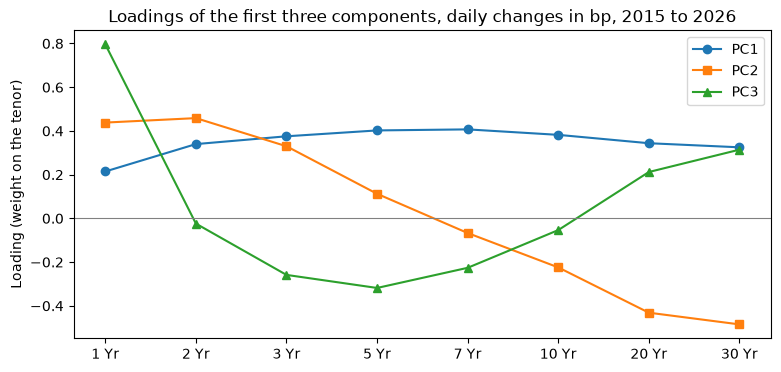

In [17]:
loadings_changes = mlkit.pca_loadings(pca_changes, tenors)[["PC1", "PC2", "PC3"]]
print(loadings_changes.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
for name, style in [("PC1", "-o"), ("PC2", "-s"), ("PC3", "-^")]:
    ax.plot(range(len(tenors)), loadings_changes[name], style, label=name)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(range(len(tenors)), tenors)
ax.set_title("Loadings of the first three components, daily changes in bp, 2015 to 2026")
ax.set_ylabel("Loading (weight on the tenor)")
ax.legend()
plt.show()

* **PC1** is positive everywhere, largest in the belly (7 Yr, 0.407) and smallest at the 1 Yr (0.215): the level shape for daily moves.
* **PC2** is positive from 1 Yr to 5 Yr and negative beyond: a slope shape. Under the sign rule it points short-end-up, long-end-down; a positive PC2 score is a day the curve moved that way.
* **PC3** is mostly one tenor: the 1 Yr carries a weight of 0.796, and no other tenor more than 0.318 either way. The 2 Yr to 10 Yr are negative and the 20 Yr and 30 Yr positive. In this file's daily moves, the third shape is largely the 1 Yr moving on its own. Curvature is the textbook name for the third component, and here the loadings show something more particular; the loadings, not the name, say what it is.

Q. Course 3 measured the slope as `2s10s` and the belly as the `2s5s10s` fly. How closely do the component scores move with them, day by day?

In [18]:
# scores of the first three components, with the loadings' signs: the centred changes times the loadings
pca3 = PCA(n_components=3).fit(changes)
scores_changes = (changes - pca3.mean_) @ mlkit.pca_loadings(pca3, tenors)

# Course 3's measures, as daily changes in bp
average_change = changes.mean(axis=1)
change_2s10s = changes["10 Yr"] - changes["2 Yr"]
change_2s5s10s = 2 * changes["5 Yr"] - changes["2 Yr"] - changes["10 Yr"]
print(f"PC1 score with the average change of the eight tenors: correlation {scores_changes['PC1'].corr(average_change):.4f}")
print(f"PC2 score with the change in 2s10s:                    correlation {scores_changes['PC2'].corr(change_2s10s):.4f}")
print(f"PC3 score with the change in the 2s5s10s fly:          correlation {scores_changes['PC3'].corr(change_2s5s10s):.4f}")

PC1 score with the average change of the eight tenors: correlation 0.9995
PC2 score with the change in 2s10s:                    correlation -0.9174
PC3 score with the change in the 2s5s10s fly:          correlation -0.4509


* These are **level, slope, and curvature scores of past dates**, compared with numbers Course 3 computed by hand on the same file.
* The PC1 score and the plain average of the eight changes are nearly the same series (0.9995). The PC2 score moves closely, and in the opposite direction, with the change in `2s10s` (-0.9174): opposite because the sign rule made PC2 short-end-up, while `2s10s` is long less short. A sign is a convention, which is why the course writes it down.
* The PC3 score and the `2s5s10s` fly share much less (-0.4509). The fly is a shape someone chose; PC3 is the shape this history produced, and it leans on the 1 Yr. Both are descriptions; they describe different things.

## 14.4 Scores Over Time, as History

A date's score on a component is how much of that component's shape the date had, relative to the average date of the file. For the levels, that gives three numbers per date for the whole span.

Q. Compute the three scores of every date from the levels PCA, and check them against scikit-learn's own `transform`.

In [19]:
pca3_levels = PCA(n_components=3).fit(levels)
loadings3 = mlkit.pca_loadings(pca3_levels, full_tenors)
# each date's yields less the average of each tenor over the file, times the loadings: percent, weighted
scores_levels = (levels - pca3_levels.mean_) @ loadings3

# transform gives the same numbers up to each component's sign, which pca_loadings may have flipped
signs = np.sign(loadings3.sum().to_numpy()) * np.sign(pca3_levels.components_.sum(axis=1))
print(f"equal to PCA.transform with the sign rule applied: {np.allclose(scores_levels, pca3_levels.transform(levels) * signs)}")

equal to PCA.transform with the sign rule applied: True


Q. Chart the three scores over the span.

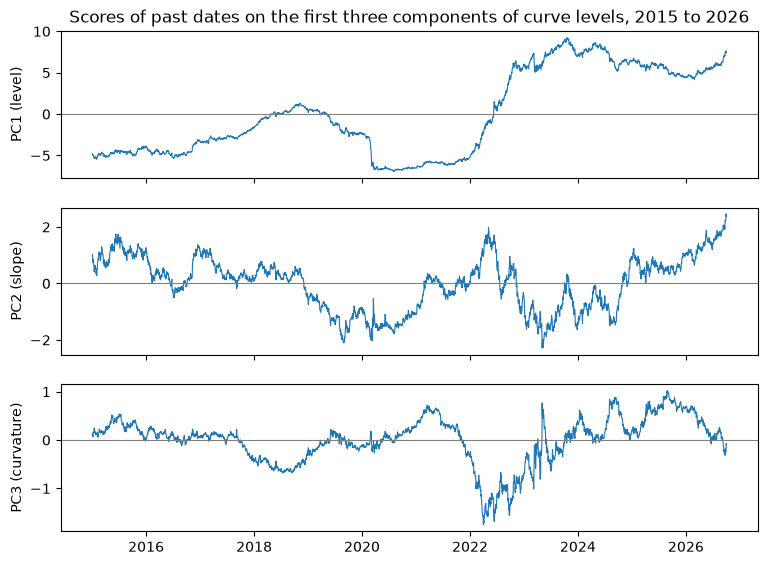

PC1: highest 9.24 on 2023-10-19, lowest -6.93 on 2020-08-04
PC2: highest 2.45 on 2026-09-30, lowest -2.29 on 2023-05-04
PC3: highest 1.02 on 2025-08-27, lowest -1.75 on 2022-04-01


In [20]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6.5), sharex=True)
for ax, name, label in zip(axes, ["PC1", "PC2", "PC3"], ["level", "slope", "curvature"]):
    ax.plot(scores_levels.index, scores_levels[name], linewidth=0.8)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_ylabel(f"{name} ({label})")
axes[0].set_title("Scores of past dates on the first three components of curve levels, 2015 to 2026")
plt.show()

# the highest and lowest date of each score
for name in ["PC1", "PC2", "PC3"]:
    high, low = scores_levels[name].idxmax(), scores_levels[name].idxmin()
    print(f"{name}: highest {scores_levels.loc[high, name]:.2f} on {high.date()}, lowest {scores_levels.loc[low, name]:.2f} on {low.date()}")

* These are **level, slope, and curvature scores of past dates**, inside the file's span. Zero is the file's average date; the units are the yields' percent, weighted by the loadings.
* The level score was lowest on 2020-08-04 and highest on 2023-10-19; it follows the average of the eleven yields almost exactly (correlation 0.9991). The slope score was lowest on 2023-05-04 and highest on 2026-09-30. It shares a good deal with Course 3's `3m10y` (correlation 0.6392) without being the same number: a score weighs all eleven tenors, and is measured from the file's average date.
* Every one of these numbers would change if the file had more or fewer dates, because the components and the averages are fitted on all of it. That is fine for describing a span. Section 14.5 shows why it is not fine for a model judged in time order.

## 14.5 PCA as a Feature Step, and Lookahead

The scores of section 14.4 were computed with a PCA fitted on every date, the last ones included. Used to describe the span, that is honest. Used as features for a model judged in time order, it is **lookahead**: a 2017 score built from components that know 2026.

The check is Course 3's idea again: compute a number up to date t, then remove every row after t from the data and compute it again. If anything changes, the number used the future.

Q. Fit a PCA on the daily changes up to one date, and score those rows. Then remove every later row from the data and do it again. Then fit on the whole history instead.

In [21]:
def window_scores(changes_up_to_t):
    """Fit a 3-component PCA on the rows given and return their scores with the sign-fixed loadings."""
    pca = PCA(n_components=3).fit(changes_up_to_t)
    return (changes_up_to_t - pca.mean_) @ mlkit.pca_loadings(pca, list(changes_up_to_t.columns))

t = changes.index[1500]
window = window_scores(changes.loc[:t])
# the same, with every row after t removed from the data first
cut = changes[changes.index <= t]
print(f"t = {t.date()}: scores fitted up to t, unchanged when later rows are removed: {window_scores(cut).equals(window)}")

# fitted on the whole history, then looked at up to t
whole = window_scores(changes).loc[:t]
print(f"fitted on the whole history, the scores of the same dates are the same: {np.allclose(whole, window, rtol=0, atol=1e-6)}")

t = 2021-01-04: scores fitted up to t, unchanged when later rows are removed: True
fitted on the whole history, the scores of the same dates are the same: False


* Fitted on rows up to 2021-01-04, the scores do not move when the later rows are deleted: they use only the past. Fitted on the whole history, the same dates get different scores: every one of them was built with rows from after 2021-01-04.
* This is exactly what the third test pins down.

Q. Add the no-lookahead test and run all the tests.

In [22]:
%%writefile -a test_mlkit.py


def test_pca_scores_no_lookahead():
    changes = curve_changes()
    t = changes.index[1500]
    # a PCA fitted on rows up to t, scored on those rows
    window = window_scores(changes.loc[:t])
    # the same, after removing every row after t from the data: nothing changes
    cut = changes[changes.index <= t]
    pd.testing.assert_frame_equal(window_scores(cut), window, check_exact=True)
    # fitted on the whole history, the scores of the same dates differ: that is lookahead
    whole = window_scores(changes).loc[:t]
    assert not np.allclose(whole.to_numpy(), window.to_numpy(), rtol=0, atol=1e-6)

Appending to test_mlkit.py


In [23]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........................................................                 [100%]
56 passed in 3.63s



* `56 passed`. `check_exact=True`: not close, identical.

**The rule.** When PCA is a step in building features for a model that is judged on rows it did not see, it goes **inside a `Pipeline`**, so it is fitted on each fold's training rows only, like a scaler. Day 11's walk-forward splits then refit it in every fold.

Q. Use three components of the 1 Yr to 20 Yr changes as features for the same day's 30 Yr change, day 11's same-day task, in a pipeline, judged walk-forward.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

features = ["1 Yr", "2 Yr", "3 Yr", "5 Yr", "7 Yr", "10 Yr", "20 Yr"]
X, y = changes[features], changes["30 Yr"]
# day 11's walk-forward folds: about two years to start, then six months at a time
splits = mlkit.walk_forward_splits(changes.index, min_train=504, test_size=126)

actual, fitted_pipeline, fitted_line = [], [], []
for train, test in splits:
    mlkit.assert_past_only(changes.index[train], changes.index[test])
    # the PCA is a step of the pipeline, so it is fitted on this fold's training rows only
    pipeline = Pipeline([("pca", PCA(n_components=3)), ("line", LinearRegression())]).fit(X.iloc[train], y.iloc[train])
    assert np.allclose(pipeline.named_steps["pca"].mean_, X.iloc[train].mean(), rtol=0, atol=1e-12)
    fitted_pipeline.append(pipeline.predict(X.iloc[test]))
    # for comparison, the straight line on all seven tenors
    fitted_line.append(LinearRegression().fit(X.iloc[train], y.iloc[train]).predict(X.iloc[test]))
    actual.append(y.iloc[test].to_numpy())

pipeline_metrics = mlkit.regression_metrics(np.concatenate(actual), np.concatenate(fitted_pipeline))
line_metrics = mlkit.regression_metrics(np.concatenate(actual), np.concatenate(fitted_line))
print(f"{len(splits)} folds, {sum(len(test) for _, test in splits):,} test days, every fold past only")
print(f"three components then a line: walk-forward MAE {pipeline_metrics['mae']:.1f} bp, R-squared {pipeline_metrics['r2']:.4f}")
print(f"the line on all seven tenors: walk-forward MAE {line_metrics['mae']:.1f} bp, R-squared {line_metrics['r2']:.4f}")

19 folds, 2,394 test days, every fold past only
three components then a line: walk-forward MAE 0.9 bp, R-squared 0.9465
the line on all seven tenors: walk-forward MAE 0.7 bp, R-squared 0.9607


* These are **out-of-sample errors inside the file's span** for a fitted 30 Yr daily change given the same day's other changes. Nothing here is about a later day.
* Every fold refitted its own PCA on its own training rows (the `assert` on `mean_` checks it). Three components give an MAE of 0.9 bp against 0.7 bp for the line on all seven tenors: a summary keeps most of the variance, not all of the detail, and the 30 Yr leans on detail the first three components leave out. PCA is a way to describe and compress, and only sometimes a better set of features.

## 14.6 Scaling Before PCA, on Mixed Units

PCA looks for the directions of greatest variance, and variance depends on units. Yields in percent share one unit. The bonds of days 12 and 13 do not: log OAS, duration in years, coupon in percent, rating score in notches.

Q. Load the bonds with the four columns of day 12.

The bonds are invented, and their spreads come from the course's generator, not from any market.

In [25]:
# the 821 synthetic benchmark bonds with their rating score; log_oas is the natural log of OAS in bp
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
bench["log_oas"] = np.log(bench["oas"])
bond_columns = ["log_oas", "duration", "coupon", "score"]
print(f"{len(bench):,} bonds of {bench['ticker'].nunique()} invented issuers")
print("standard deviation of each column, in its own units:", bench[bond_columns].std(ddof=0).round(3).to_dict())

821 bonds of 150 invented issuers
standard deviation of each column, in its own units: {'log_oas': 0.735, 'duration': 3.251, 'coupon': 1.654, 'score': 3.431}


Q. Run PCA on the four columns as they are, then after `StandardScaler`. Compare the first component and the variance.

In [26]:
from sklearn.preprocessing import StandardScaler

pca_raw = PCA().fit(bench[bond_columns])
# a demonstration on the whole file: nothing is tested here, so the scaler is fitted on every bond
scaled = StandardScaler().fit_transform(bench[bond_columns])
pca_scaled = PCA().fit(scaled)

comparison = pd.DataFrame({
    "PC1 loadings, raw": mlkit.pca_loadings(pca_raw, bond_columns)["PC1"],
    "PC1 loadings, scaled": mlkit.pca_loadings(pca_scaled, bond_columns)["PC1"],
    "PC2 loadings, scaled": mlkit.pca_loadings(pca_scaled, bond_columns)["PC2"],
})
print(comparison.round(3))
print()
print(pd.DataFrame({"raw": mlkit.explained_table(pca_raw)["explained_pct"],
                    "scaled": mlkit.explained_table(pca_scaled)["explained_pct"]}).round(2))

          PC1 loadings, raw  PC1 loadings, scaled  PC2 loadings, scaled
log_oas               0.179                 0.602                -0.008
duration             -0.252                -0.005                 0.981
coupon                0.317                 0.542                 0.151
score                 0.897                 0.586                -0.123

       raw  scaled
PC1  54.46   64.96
PC2  40.72   25.70
PC3   4.62    7.94
PC4   0.20    1.41


* Unscaled, PC1 is mostly rating score (loading 0.897) and PC2 mostly duration: the two columns with the largest standard deviations in their own units (3.43 notches and 3.25 years). Log OAS, with a standard deviation of 0.74, barely enters until the fourth component. That is a statement about units, not about bonds: measure duration in months and it would take over PC1.
* Scaled, every column starts with the same variance. PC1 now weighs log OAS, coupon, and score about equally (0.602, 0.542, 0.586) and carries 64.96 percent; PC2 is duration on its own (0.981). In this file, spread, coupon, and rating move together, and duration varies apart from them, as the generator built it: spread comes from rating and maturity, and each coupon from the bond's yield plus noise.
* The rule from day 12 holds for PCA: when columns have different units, scale first.

## 14.7 t-SNE: A Picture of Many Columns

PCA keeps straight-line directions, so two components can be read: each axis is a weighted sum of the columns. **t-SNE** (t-distributed stochastic neighbour embedding) does something else. It places each row on a flat page so that rows that are near each other in all the columns tend to stay near each other on the page. It bends the space to do it.

What that means for reading a t-SNE picture:

| Can be trusted for | Cannot be trusted for |
| --- | --- |
| Which rows sit near which: a tight group of points is usually a group of similar rows | Distances between groups: two groups far apart on the page may not be far apart in the data |
| A first look at whether the rows fall into groups at all | Sizes of groups: t-SNE spreads dense groups out and pulls sparse ones in |
| | The axes: they have no units and no meaning, and change from run to run of a different seed |
| | Anything printed: a coordinate invites a reading the method does not support |

So in this course **t-SNE is charted only**. No coordinate, distance, or cluster read from it is printed. Two settings are written out: `random_state=SEED`, because t-SNE starts from a random layout, and `perplexity`, roughly how many neighbours each point pays attention to, which changes the picture.

Q. Draw the scaled bonds with t-SNE at perplexity 5, 30, and 50, coloured by rating score.

The bonds are invented; the picture describes the course's generator.

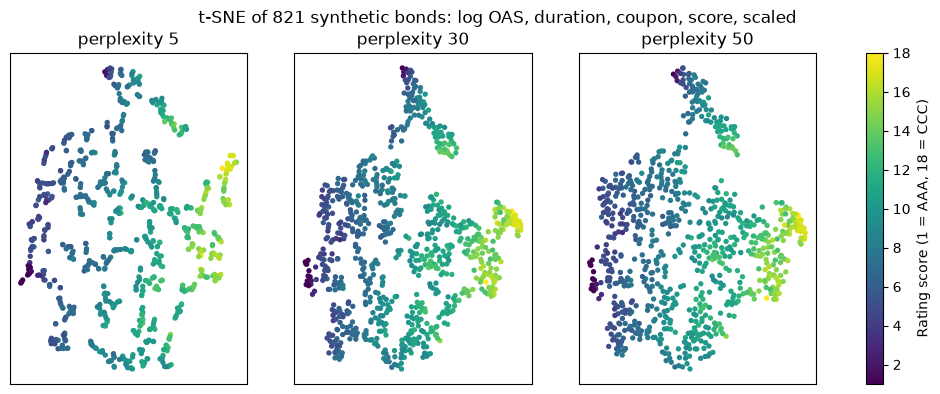

In [27]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, perplexity in zip(axes, [5, 30, 50]):
    # the same scaled columns as section 14.6; the seed fixes the starting layout
    picture = TSNE(n_components=2, perplexity=perplexity, random_state=SEED).fit_transform(scaled)
    points = ax.scatter(picture[:, 0], picture[:, 1], c=bench["score"], cmap="viridis", s=8)
    ax.set_title(f"perplexity {perplexity}")
    # the axes of a t-SNE picture have no units and no meaning, so they carry no ticks
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(points, ax=axes, label="Rating score (1 = AAA, 18 = CCC)")
fig.suptitle("t-SNE of 821 synthetic bonds: log OAS, duration, coupon, score, scaled")
plt.show()

* Colour runs smoothly across each picture: bonds of neighbouring rating scores sit near each other, because score, coupon, and spread move together in the scaled columns. That much is a neighbourhood fact, the kind t-SNE keeps.
* The three pictures differ. At perplexity 5 the bonds string out into many short strands; at 30 and 50 they gather into one large shape with a separate arm at the top. Same bonds, same columns, same seed: the groups you see depend on a setting. That is why a t-SNE picture is a first look and never a measurement, and why clusters are found and profiled with the tools of days 12 and 13, in the data's own units.

## Excel Side by Side

**Excel has no PCA function, and no t-SNE.** It cannot find components. It can do every step around them: the changes, the correlations and covariances, the scores once the loadings are known, and a check that a set of loadings really is a component. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-04) on a workbook laid out like this: sheet `curve`, the eight yields of 1 Yr to 30 Yr in percent in `B2:I2941`, headers in row 1, and the daily changes in bp in `K3:R2941`; sheet `loadings`, the PC1 to PC3 loadings of section 14.3's three-component PCA (sign rule applied) in `B2:D9`, one row per tenor.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Daily change in bp | `curve[tenors].diff() * 100` | `=(B3-B2)*100` in K3, filled right and down | equal to pandas exactly |
| Correlation of two tenors' changes | `changes.corr()` | `=CORREL(curve!P3:P2941,curve!Q3:Q2941)` (10 Yr, 20 Yr) | 0.9529 |
| Covariance, sample | `np.cov(changes, rowvar=False)` | `=COVARIANCE.S(curve!L3:L2941,curve!P3:P2941)` (2 Yr, 10 Yr) | 20.9902 bp squared |
| Scores | `(changes - pca.mean_) @ loadings` | `=MMULT(K3:R2941-BYCOL(K3:R2941,LAMBDA(c,AVERAGE(c))),loadings!B2:D9)` | spills 2,939 rows by 3 |
| Not the scores | | `=MMULT(K3:R2941,loadings!B2:D9)` | off by up to 0.333 bp |
| Check a component | `pca.explained_variance_[0]` | `=MMULT(stats!B12:I19,loadings!B2:B9)/loadings!B2:B9` | 181.4263 on all 8 rows |
| PC1's share of variance | `explained_table(...)` | `=F2/H2`, with `=SUMPRODUCT(stats!B12:I19*MUNIT(8))` in H2 | 85.04 percent |

**The changes.** `=(B3-B2)*100` in K3 is today's 1 Yr less yesterday's, times 100 for bp; fill it right across the eight tenors and down to the last date. It gives the same 2,939 by 8 numbers as pandas, exactly.

**Correlations and covariances.** One `CORREL` or `COVARIANCE.S` per pair of tenors, 64 cells for each table. `COVARIANCE.S` is the sample covariance, dividing by n - 1, which is what `np.cov` and scikit-learn's PCA use.

**The scores, and the trap.** `BYCOL(K3:R2941,LAMBDA(c,AVERAGE(c)))` returns the eight column averages as one row, and subtracting it from the block centres every change. `MMULT` of the centred block and the loadings is the score table, one formula that spills 2,939 rows by 3. Leave the centring out, `=MMULT(K3:R2941,loadings!B2:D9)`, and every row comes out shifted by the column averages times the loadings, the same amount on every row: 0.333 bp on PC1, 0.057 on PC2, 0.063 on PC3. A score is measured from the average date, so the average has to come out first. `BYCOL` and `LAMBDA` need an Excel with dynamic arrays.

**Checking a component.** A component's loadings are a direction the covariance matrix only stretches: the covariance matrix times the loadings gives the loadings again, times one number. `=MMULT(covariance, PC1 loadings)/PC1 loadings` returned the same number on all eight rows, 181.4263, PC1's variance in bp squared. Divided by the total of the eight variances, `SUMPRODUCT(covariance*MUNIT(8))` (the diagonal of the covariance table), it is PC1's share. So Excel can confirm loadings it is given; it has no function that finds them.

In [28]:
# Excel's numbers, from the day's Excel check, beside Python's for the same rows and the same loadings
covariance = changes.cov()
loadings3_changes = mlkit.pca_loadings(pca3, tenors)
excel = {"CORREL, 10 Yr and 20 Yr": 0.9529200494080029,
         "COVARIANCE.S, 2 Yr and 10 Yr": 20.990185276246724,
         "score, first date, PC1": -13.35017048762187,
         "score, last date, PC3": -1.5559794439172543,
         "PC1 variance (MMULT check)": 181.42625848265087,
         "PC1 share of variance": 0.850383049414425}
python = {"CORREL, 10 Yr and 20 Yr": changes["10 Yr"].corr(changes["20 Yr"]),
          "COVARIANCE.S, 2 Yr and 10 Yr": covariance.loc["2 Yr", "10 Yr"],
          "score, first date, PC1": scores_changes["PC1"].iloc[0],
          "score, last date, PC3": scores_changes["PC3"].iloc[-1],
          "PC1 variance (MMULT check)": pca3.explained_variance_[0],
          "PC1 share of variance": pca3.explained_variance_ratio_[0]}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-9"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-9
print(side_by_side.round(4))

# the raw MMULT: the first date's three numbers less its scores, and the column averages times the loadings
excel_raw_first = np.array([-13.017536734428978, 11.086692150974052, -0.44535541574532633])
print(f"raw MMULT less the scores, first date (bp): {(excel_raw_first - scores_changes.iloc[0].to_numpy()).round(3).tolist()}")
print(f"column averages times the loadings (bp):    {(pca3.mean_ @ loadings3_changes.to_numpy()).round(3).tolist()}")

                                 Excel    Python  within 1e-9
CORREL, 10 Yr and 20 Yr         0.9529    0.9529         True
COVARIANCE.S, 2 Yr and 10 Yr   20.9902   20.9902         True
score, first date, PC1        -13.3502  -13.3502         True
score, last date, PC3          -1.5560   -1.5560         True
PC1 variance (MMULT check)    181.4263  181.4263         True
PC1 share of variance           0.8504    0.8504         True
raw MMULT less the scores, first date (bp): [0.333, 0.057, 0.063]
column averages times the loadings (bp):    [0.333, 0.057, 0.063]


* Every number matches, and the raw `MMULT`'s error is exactly the averages times the loadings. Centre first.

## Save the Day with Git

Today ends the teaching days of week 3; tomorrow is the capstone. The work folder gets the module, the experiment log, and a **tag**: a name fixed to one commit, so the state of the module at the end of the teaching days can always be found again.

Q. Make the work folder a repository.

In [29]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [30]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_14_vuzyhn5p and nowhere else


Q. Tell Git which files never to track, then commit the module and its tests.

In [31]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [32]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "mlkit: pca_loadings and explained_table, with three tests"
!git -C "{work}" log --oneline

0f062d7 mlkit: pca_loadings and explained_table, with three tests


Q. Write the walk-forward test metrics of section 14.5's pipeline to `results.csv`, with 4 decimals, and commit them.

`train_rows` is the last fold's training rows; `test_rows` counts every fold's test days together, because the walk-forward metrics are pooled over them.

In [33]:
# one row: what the model is, its rows, and its pooled walk-forward test metrics (MAE and RMSE in bp)
results = pd.DataFrame([{
    "model": "pca3_then_line_walk_forward",
    "features": "1 Yr to 20 Yr daily changes, 3 components",
    "train_rows": len(splits[-1][0]),
    "test_rows": sum(len(test) for _, test in splits),
    "test_r2": pipeline_metrics["r2"],
    "test_mae_bp": pipeline_metrics["mae"],
    "test_rmse_bp": pipeline_metrics["rmse"],
}])
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
pca3_then_line_walk_forward,"1 Yr to 20 Yr daily changes, 3 components",2772,2394,0.9465,0.8558,1.1744



In [34]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: walk-forward test metrics of three curve components then a line"

Q. Tag the last commit `week3-teaching`, and show the history with its labels.

In [35]:
# a tag names one commit; --decorate shows the branch and tag labels beside each commit
!git -C "{work}" tag week3-teaching
!git -C "{work}" log --oneline --decorate

6c91640 (HEAD -> main, tag: week3-teaching) Experiment log: walk-forward test metrics of three curve components then a line


0f062d7 mlkit: pca_loadings and explained_table, with three tests


* `HEAD -> main` is where you are; `tag: week3-teaching` sits on the same commit. A tag does not move when you commit again, so `git diff week3-teaching -- mlkit.py` will always show what changed in the module since the end of the teaching days.

## Bring It Home

Add today's functions and tests to your own folder. The Treasury file is already there from day 11. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste the code of today's two `%%writefile -a mlkit.py` cells (section 14.2), without their first lines, at the end of `mlkit.py`, and the two `%%writefile -a test_mlkit.py` cells (sections 14.2 and 14.5) at the end of `test_mlkit.py`. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `56 passed`.

**Step 4.** Read what changed, commit the code, and tag it.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "mlkit: pca_loadings and explained_table, with three tests"
git tag week3-teaching
git log --oneline --decorate -3
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say why many correlated columns can be summarised by a few, and measure how few with `explained_table`.
* Fit a PCA, read its loadings as shapes, and name the shapes level, slope, and curvature only where the loadings show them.
* Fix a component's arbitrary sign with `pca_loadings`, so reruns and other tools agree.
* Compute scores as the centred data times the loadings, chart them as history, and tie them to Course 3's slope and fly.
* Keep PCA inside a pipeline when it builds features, and prove with the no-lookahead check that a fitted PCA used no later rows.
* Scale before PCA when the columns have different units.
* Draw a t-SNE picture with its seed and perplexity written out, and say what it can and cannot be trusted for.
* Check PCA scores and a component in Excel with `COVARIANCE.S`, `MMULT`, and `BYCOL`, and say that Excel cannot find components.

Tomorrow is the capstone: a real file of company financial ratios, three models compared on rows they never saw, with every rule of the course in one place: split first, fit inside pipelines, choose on training folds, open the test rows once, and describe what the model shows and where it fails.

## Exercises

The exercises use the same Treasury file (real, U.S. Treasury, public domain), describing its history from 2015-01-02 to 2026-10-02 and nothing after. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the curve, makes the daily changes and day 11's walk-forward folds, and defines `check`, a small function that marks your answers.

In [36]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# the curve in percent, and the 1 Yr to 30 Yr daily changes in bp
curve = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
tenors = ["1 Yr", "2 Yr", "3 Yr", "5 Yr", "7 Yr", "10 Yr", "20 Yr", "30 Yr"]
changes = (curve[tenors].diff() * 100).dropna()
features = ["1 Yr", "2 Yr", "3 Yr", "5 Yr", "7 Yr", "10 Yr", "20 Yr"]
splits = mlkit.walk_forward_splits(changes.index, min_train=504, test_size=126)
pca_changes = PCA().fit(changes)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Run PCA on the levels of the 2 Yr to 30 Yr only (seven tenors, in percent, every date). Store the percent of variance its first component carries, from `explained_table`, in **ex1_pc1_pct**.

In [37]:
ex1_pc1_pct = ...

In [38]:
check("Exercise 1 PC1 of the 2 Yr to 30 Yr levels", ex1_pc1_pct, 97.23707819875297)

Exercise 1 PC1 of the 2 Yr to 30 Yr levels: not attempted yet


### Exercise 2

Q. Fit a PCA to the daily changes of 2015 to 2019, and another to those of 2022 to 2026 (`changes.loc["2015":"2019"]` and `changes.loc["2022":"2026"]`). Store a dictionary with the keys `"2015 to 2019"` and `"2022 to 2026"` and each period's PC1 percent of variance, rounded to 2 decimals, in **ex2_pc1_by_period**.

In [39]:
ex2_pc1_by_period = ...

In [40]:
check("Exercise 2 PC1 by period", ex2_pc1_by_period, {'2015 to 2019': 87.68, '2022 to 2026': 86.7})

Exercise 2 PC1 by period: not attempted yet


### Exercise 3

Q. Add a function to your module. `components_for(pca, share)` returns how many components of a fitted PCA it takes for the cumulative percent of variance to reach `share`, given in percent (95 means 95 percent). It should use `explained_table`, raise `ValueError` if `share` is not above 0 and at most 100, and raise `ValueError` if the PCA kept too few components to reach it. Write the docstring first. Then add `test_components_for_hand_and_limits`, using the tests' `curve_changes()` helper. Run pytest, reload the module, and store `mlkit.components_for(pca_changes, 98)` in **ex3_components**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [41]:
%%writefile -a mlkit.py


# Exercise 3: write components_for(pca, share) below this line

Appending to mlkit.py


In [42]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_components_for_hand_and_limits() below this line

Appending to test_mlkit.py


In [43]:
# run pytest, reload the module, then call your function
ex3_components = ...

In [44]:
check("Exercise 3 components_for 98 percent", ex3_components, 3)

Exercise 3 components_for 98 percent: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that evaluates one walk-forward fold of section 14.5's model, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Walk-forward evaluation of one fold with PCA features, and no lookahead.

    Features: the 1 Yr to 20 Yr daily changes in bp; target: the same day's 30 Yr change in bp.
    A 3-component PCA and a straight line are fitted on the fold's training rows only, then the
    fold's test rows are scored. Nothing may depend on a row after the fold's last test date.
    Returns: the test MAE in bp, and the training rows' PCA scores (a DataFrame indexed by date).
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a number of the right size, and contains one bug.

In [45]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def fold_mae_with_pca(changes, train, test):
    """Walk-forward evaluation of one fold with PCA features, and no lookahead.

    Features: the 1 Yr to 20 Yr daily changes in bp; target: the same day's 30 Yr change in bp.
    A 3-component PCA and a straight line are fitted on the fold's training rows only, then the
    fold's test rows are scored. Nothing may depend on a row after the fold's last test date.
    Returns: the test MAE in bp, and the training rows' PCA scores (a DataFrame indexed by date).
    """
    X = changes[features]
    y = changes["30 Yr"]
    # fit the PCA once on the whole history, so the components are as stable as possible
    pca = PCA(n_components=3).fit(X)
    scores = pd.DataFrame(pca.transform(X.iloc[train]), index=X.index[train], columns=["PC1", "PC2", "PC3"])
    line = LinearRegression().fit(scores.to_numpy(), y.iloc[train])
    fitted = line.predict(pca.transform(X.iloc[test]))
    return mlkit.regression_metrics(y.iloc[test], fitted)["mae"], scores

Q. Before you run the next cell: will the first fold's MAE be higher than, equal to, or lower than the same fold done with section 14.5's pipeline, which refits the PCA on the fold's training rows?

In [46]:
train, test = splits[0]
mae_ai, scores_ai = fold_mae_with_pca(changes, train, test)
X, y = changes[features], changes["30 Yr"]
pipeline = Pipeline([("pca", PCA(n_components=3)), ("line", LinearRegression())]).fit(X.iloc[train], y.iloc[train])
mae_pipeline = mlkit.regression_metrics(y.iloc[test], pipeline.predict(X.iloc[test]))["mae"]
print(f"first fold, fold_mae_with_pca: {mae_ai:.1f} bp; with the pipeline: {mae_pipeline:.1f} bp")

first fold, fold_mae_with_pca: 0.8 bp; with the pipeline: 0.8 bp


Q. Test the function against its docstring before you trust it. The docstring says nothing may depend on a row after the fold's last test date, which is Course 3's no-lookahead check.

In [47]:
# the test, written from the docstring before the code is trusted: the no-lookahead check
train, test = splits[0]
mae_all, scores_all = fold_mae_with_pca(changes, train, test)
# remove every row after the fold's last test date from the data, and run it again
last_test_date = changes.index[test[-1]]
mae_cut, scores_cut = fold_mae_with_pca(changes.loc[:last_test_date], train, test)
assert scores_cut.equals(scores_all), "the training scores change when later rows are removed: they use later rows"
assert mae_cut == mae_all, "the test MAE changes when later rows are removed"
print("fold_mae_with_pca uses no row after the fold")

AssertionError: the training scores change when later rows are removed: they use later rows

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's first-fold MAE in bp, `fold_mae_with_pca(changes, *splits[0])[0]`, in **ex4_fold_mae_bp**.

In [48]:
# fix the function above and run the test again, then store the answer
ex4_fold_mae_bp = ...

In [49]:
check("Exercise 4 the fixed function's first-fold MAE", ex4_fold_mae_bp, 0.7913278768566839)

Exercise 4 the fixed function's first-fold MAE: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```